In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns



df = pd.read_excel(r"H:\Meth_Pr\data\Sleep_Work_Productivity_Surve2026-04-24_13_03_21.xlsx")
# clean age column

df['Enter your age ?']= df['Enter your age ?'].fillna(df['Enter your age ?'].median())

# rename the columns

df.rename(columns={
    'How would you rate your overall work productivity?': 'work_productivity',
    'How much do you think your sleep affects your productivity at work?': 'sleep_productivity_effect',
    'What factors do you believe impact your sleep quality? (Select all that apply)': 'sleep_factors',
    'How many breaks do you take during your workday when you are tired ?': 'break_nums',
    'How would you describe your energy levels throughout the workday?': 'energy_levels_per_workday',
    'What is your primary work environment?': 'primary_work_environment',
    'what is you gender ?': 'gender',
    'On a typical work night, how many hours of sleep do you get?': 'sleep_hours',
    
    'I wake up feeling refreshed and ready for work.':
        'wake_up_refreshed',

    'I have difficulty falling asleep the night before an important workday.':
        'difficulty_falling_asleep',

    'Enter your age ?':
        'age',

    'I wake up multiple times during the night and struggle to go back to sleep.':
        'wake_up_multiple_times',

    'On weekends or days off, my sleep schedule is very different from my workday schedule (e.g., sleeping in more than 2 hours later).':
        'weekend_sleep_schedule_difference',

    'I use electronic devices (phone, laptop, TV) in bed within 30 minutes of trying to sleep.':
        'device_use_before_sleep',

    'I find it hard to concentrate on work tasks for more than 15–20 minutes at a time.':
        'difficulty_concentrating',

    'I make careless mistakes (e.g., typos, miscalculations, forgetting steps) that I would not have made if better rested.':
        'careless_mistakes',

    'I often have to re-read emails, documents, or instructions because I lost focus.':
        'reread_due_to_focus_loss',

    'Learning a new software, process, or skill at work feels unusually difficult for me.':
        'difficulty_learning_new_skills',

    'I struggle to generate new ideas or creative solutions to problems.':
        'difficulty_generating_ideas',

    'I forget important tasks, deadlines, or details from meetings.':
        'forget_tasks_deadlines',

    'I feel irritable or short-tempered with colleagues or clients.':
        'irritable_with_colleagues',

    'Small setbacks or minor criticism feel overwhelming or upsetting.':
        'small_setbacks_overwhelming',

    'I avoid collaboration or group work because I feel mentally exhausted.':
        'avoid_collaboration',

    'I have difficulty controlling my emotions during stressful work situations (e.g., tight deadlines, difficult customers).':
        'difficulty_controlling_emotions',

    'I feel physically tired, sluggish, or heavy-eyed during work, even without heavy physical exertion.':
        'physically_tired_at_work',

    'In my job, I have had a close call, minor accident, or injury that I attribute to being too tired. If your job is sedentary, answer based on accidents like tripping, bumping into things, or spilling hot liquids.':
        'accident_due_to_tiredness',

    'Compared to when I am well-rested, I estimate my current work output is...':
        'current_work_output',

    'In the past month, how many work days did you feel you were “present but not productive” (getting less than half of your normal output) due to poor sleep?':
        'unproductive_workdays_due_to_sleep'

}, inplace=True)


df = df.replace(r'\n', ', ', regex=True)
df["sleep_factors"] = df["sleep_factors"].str.split(", ")

# index

df['sleep_quality_and_hygiene_index_(SQLI)']=(df['wake_up_refreshed']+df['difficulty_falling_asleep']+df['wake_up_multiple_times']+df['weekend_sleep_schedule_difference']+df['device_use_before_sleep'])*100/25
df['Cognitive_at_task_perforamnce_index_(CTPI)']=(((df['difficulty_concentrating']+df['careless_mistakes']+df['reread_due_to_focus_loss']+df['difficulty_learning_new_skills']+df['difficulty_generating_ideas']+df['forget_tasks_deadlines'])*100/30).round(2))
df['Emotional_and_social_impact_index(ESII)']=((df['irritable_with_colleagues']+df['small_setbacks_overwhelming']+df['avoid_collaboration']+df['difficulty_controlling_emotions'])*100/20)
df['Physical_and_safety_risk_index(PSRI)']=((df['physically_tired_at_work']+df['accident_due_to_tiredness'])*100/10)
df['Presentative_index(PI)']=(((df['unproductive_workdays_due_to_sleep'])*100/50).round(2))
df['Overall_sleep_Productivity_Impact_index(SPI)']=((df['Cognitive_at_task_perforamnce_index_(CTPI)']+df['Emotional_and_social_impact_index(ESII)']+df['Physical_and_safety_risk_index(PSRI)']+df['Presentative_index(PI)'])*0.3)


In [2]:
df[['age', 'sleep_quality_and_hygiene_index_(SQLI)', 'Cognitive_at_task_perforamnce_index_(CTPI)', 'Emotional_and_social_impact_index(ESII)', 'Physical_and_safety_risk_index(PSRI)', 'Presentative_index(PI)', 'Overall_sleep_Productivity_Impact_index(SPI)']].corr()

,age,sleep_quality_and_hygiene_index_(SQLI),Cognitive_at_task_perforamnce_index_(CTPI),Emotional_and_social_impact_index(ESII),Physical_and_safety_risk_index(PSRI),Presentative_index(PI),Overall_sleep_Productivity_Impact_index(SPI)
age,1.000000,-0.060557,-0.426361,-0.298238,-0.322648,-0.411070,-0.495280
sleep_quality_and_hygiene_index_(SQLI),-0.060557,1.000000,0.143256,0.069303,0.289708,0.058211,0.197351
Cognitive_at_task_perforamnce_index_(CTPI),-0.426361,0.143256,1.000000,0.415589,0.415101,0.525395,0.794562
Emotional_and_social_impact_index(ESII),-0.298238,0.069303,0.415589,1.000000,0.482213,0.227472,0.729320
Physical_and_safety_risk_index(PSRI),-0.322648,0.289708,0.415101,0.482213,1.000000,0.221271,0.744351
Presentative_index(PI),-0.411070,0.058211,0.525395,0.227472,0.221271,1.000000,0.658436
Overall_sleep_Productivity_Impact_index(SPI),-0.495280,0.197351,0.794562,0.729320,0.744351,0.658436,1.000000


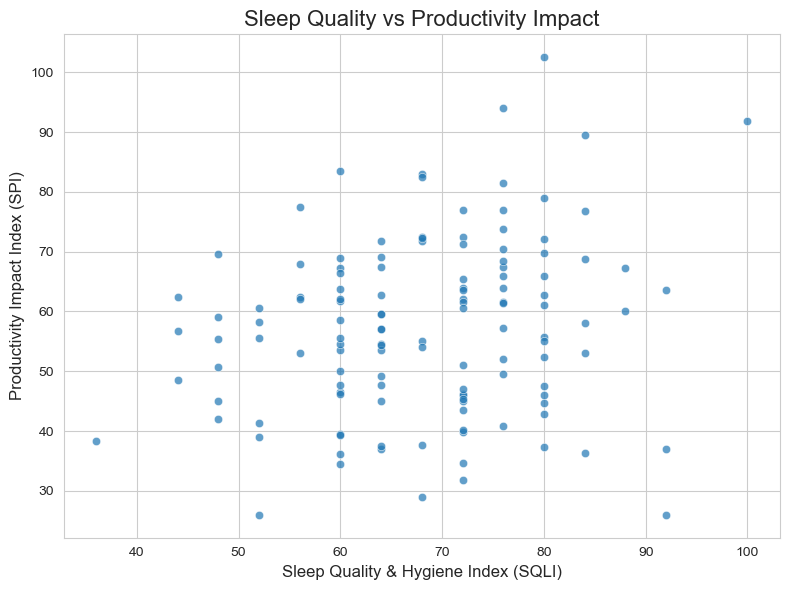

In [3]:
sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df['sleep_quality_and_hygiene_index_(SQLI)'],
    y=df['Overall_sleep_Productivity_Impact_index(SPI)'],
    alpha=0.7
)

plt.title('Sleep Quality vs Productivity Impact', fontsize=16)
plt.xlabel('Sleep Quality & Hygiene Index (SQLI)', fontsize=12)
plt.ylabel('Productivity Impact Index (SPI)', fontsize=12)

plt.tight_layout()
plt.show()

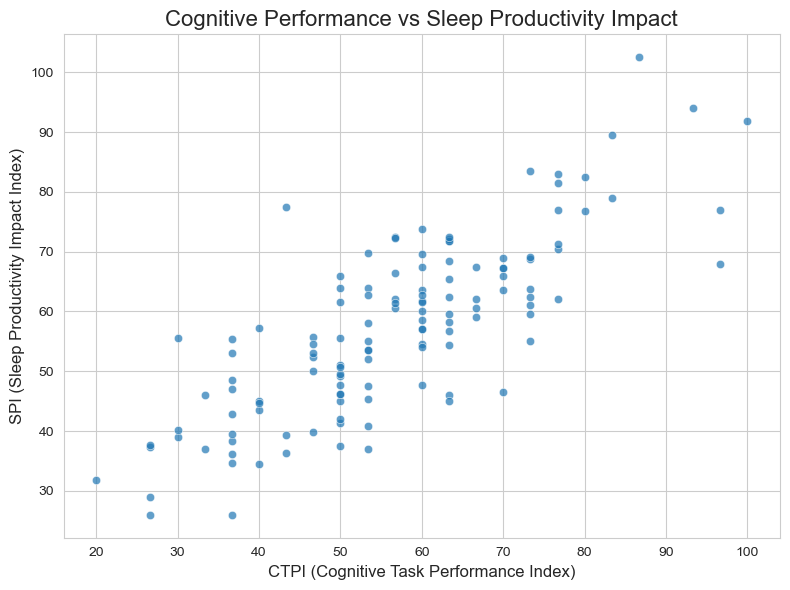

In [4]:
sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df['Cognitive_at_task_perforamnce_index_(CTPI)'],
    y=df['Overall_sleep_Productivity_Impact_index(SPI)'],
    alpha=0.7
)

plt.title('Cognitive Performance vs Sleep Productivity Impact', fontsize=16)
plt.xlabel('CTPI (Cognitive Task Performance Index)', fontsize=12)
plt.ylabel('SPI (Sleep Productivity Impact Index)', fontsize=12)

plt.tight_layout()
plt.show()

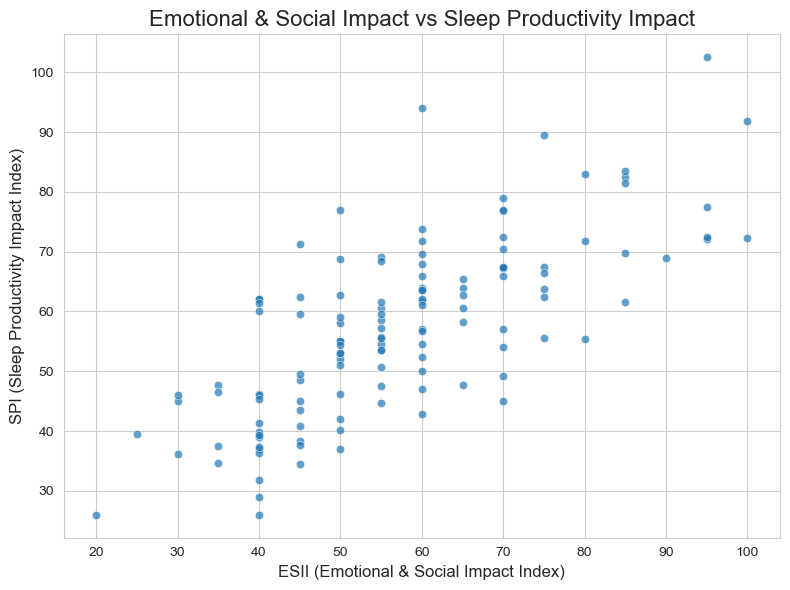

In [5]:
sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df['Emotional_and_social_impact_index(ESII)'],
    y=df['Overall_sleep_Productivity_Impact_index(SPI)'],
    alpha=0.7
)

plt.title('Emotional & Social Impact vs Sleep Productivity Impact', fontsize=16)
plt.xlabel('ESII (Emotional & Social Impact Index)', fontsize=12)
plt.ylabel('SPI (Sleep Productivity Impact Index)', fontsize=12)

plt.tight_layout()
plt.show()

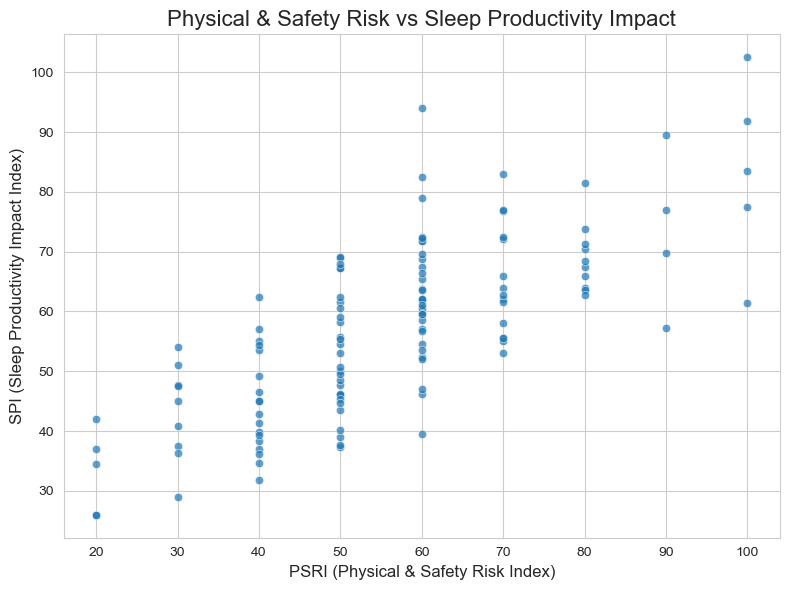

In [6]:
sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df['Physical_and_safety_risk_index(PSRI)'],
    y=df['Overall_sleep_Productivity_Impact_index(SPI)'],
    alpha=0.7
)

plt.title('Physical & Safety Risk vs Sleep Productivity Impact', fontsize=16)
plt.xlabel('PSRI (Physical & Safety Risk Index)', fontsize=12)
plt.ylabel('SPI (Sleep Productivity Impact Index)', fontsize=12)

plt.tight_layout()
plt.show()

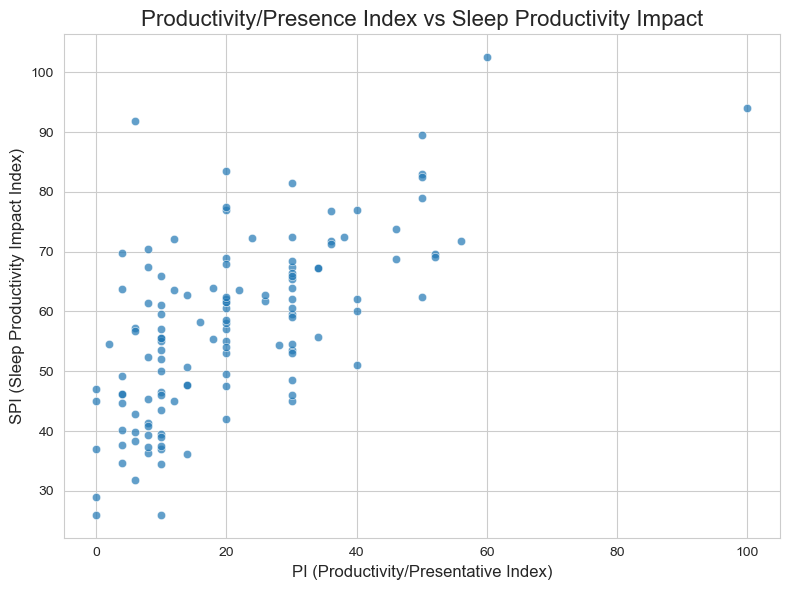

In [7]:
sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df['Presentative_index(PI)'],
    y=df['Overall_sleep_Productivity_Impact_index(SPI)'],
    alpha=0.7
)

plt.title('Productivity/Presence Index vs Sleep Productivity Impact', fontsize=16)
plt.xlabel('PI (Productivity/Presentative Index)', fontsize=12)
plt.ylabel('SPI (Sleep Productivity Impact Index)', fontsize=12)

plt.tight_layout()
plt.show()

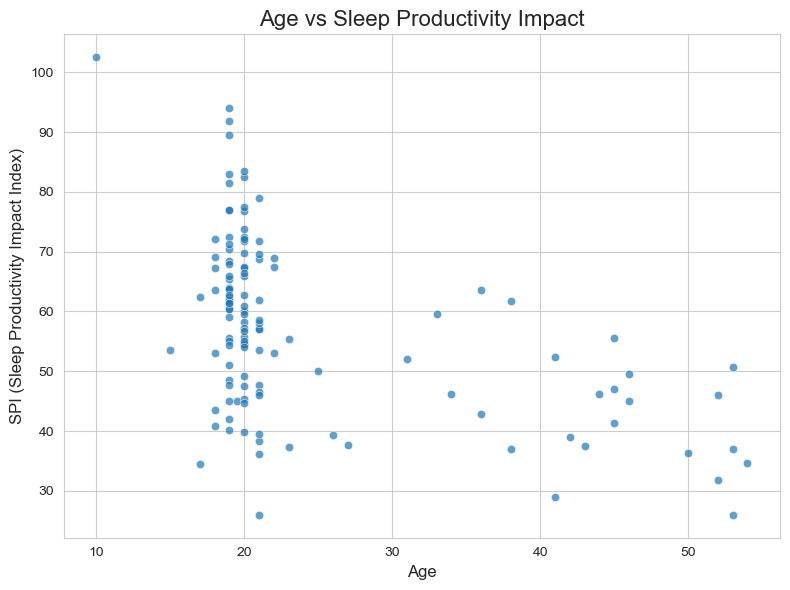

In [8]:
sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df['age'],
    y=df['Overall_sleep_Productivity_Impact_index(SPI)'],
    alpha=0.7
)

plt.title('Age vs Sleep Productivity Impact', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('SPI (Sleep Productivity Impact Index)', fontsize=12)

plt.tight_layout()
plt.show()

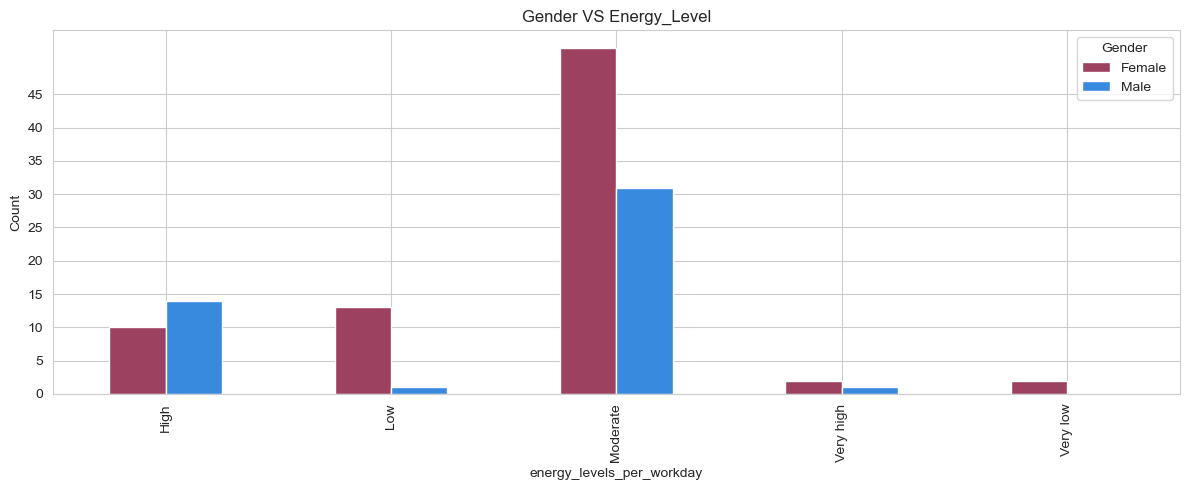

In [9]:
df['sf_list'] = df['energy_levels_per_workday']
df_exp = df[['gender', 'sf_list']]
df_exp = df_exp[df_exp['gender'] != 'Prefer not to say']
ct = pd.crosstab(df_exp['sf_list'], df_exp['gender'])
ax = ct.plot(kind='bar', color=["#9D4160", '#378ADD'], figsize=(12, 5))
plt.title('Gender VS Energy_Level')
plt.xlabel('energy_levels_per_workday')
plt.ylabel('Count')
plt.yticks(range(0, 50, 5))
plt.legend(title='Gender')
plt.tight_layout()
plt.show()